In [2]:
import pandas as pd
df_old=pd.read_csv("spam.csv",encoding="latin-1")
df_old.head()
df_new=pd.read_csv("Dataset_5971.csv",encoding="latin-1")
df_new.head()

,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Your opinion about me? 1. Over 2. Jada 3. Kusr...,No,No,No
1,ham,What's up? Do you want me to come online? If y...,No,No,No
2,ham,So u workin overtime nigpun?,No,No,No
3,ham,"Also sir, i sent you an email about how to log...",No,No,No
4,Smishing,Please Stay At Home. To encourage the notion o...,No,No,No


In [3]:
!pip install pandas


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df_old.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"], inplace=True)
df_old.rename(columns={"v1":"target","v2":"text"},inplace=True)
df_new.rename(columns={"LABEL":"target","TEXT":"text"},inplace=True)

In [5]:
df_new.drop(columns=["URL","EMAIL","PHONE"],inplace=True)
df_new["target"]=df_new["target"].replace("Smishing","spam")
df_new["target"]=df_new["target"].replace("Spam","spam")
df_new["target"]=df_new["target"].replace("smishing","spam")
print(df_new["target"].value_counts())

target
ham     4844
spam    1127
Name: count, dtype: int64


In [6]:
df=pd.concat([df_new,df_old],ignore_index=True)
df.shape

(11543, 2)

In [7]:
!pip install scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df["target"]=encoder.fit_transform(df["target"])
df.head()

,target,text
0,0,Your opinion about me? 1. Over 2. Jada 3. Kusr...
1,0,What's up? Do you want me to come online? If y...
2,0,So u workin overtime nigpun?
3,0,"Also sir, i sent you an email about how to log..."
4,1,Please Stay At Home. To encourage the notion o...


In [9]:
print("missing values:")
print(df.isnull().sum())
print("\nduplicates:")
print(df.duplicated().sum())

missing values:
target    0
text      0
dtype: int64

duplicates:
4735


In [10]:
df=df.drop_duplicates(keep="first")
df.shape
df.head()

,target,text
0,0,Your opinion about me? 1. Over 2. Jada 3. Kusr...
1,0,What's up? Do you want me to come online? If y...
2,0,So u workin overtime nigpun?
3,0,"Also sir, i sent you an email about how to log..."
4,1,Please Stay At Home. To encourage the notion o...


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(6808, 2)

In [13]:
df["target"].value_counts()

target
0    5399
1    1409
Name: count, dtype: int64

In [14]:
!pip install matplotlib



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


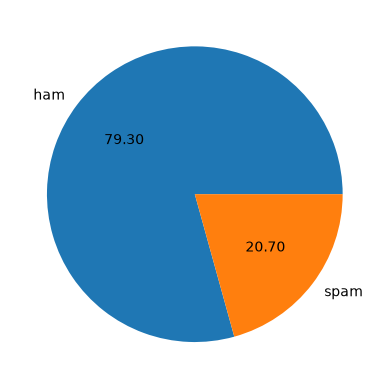

In [15]:
import matplotlib.pyplot as plt
plt.pie(df["target"].value_counts() , labels=["ham","spam"],autopct="%0.2f")

In [16]:
!pip install nltk
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package punkt to C:\Users\Yashvendra
[nltk_data]     Vyas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Yashvendra
[nltk_data]     Vyas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [17]:
import nltk
df["num_char"]=df["text"].apply(len)

In [18]:
df.head()

,target,text,num_char
0,0,Your opinion about me? 1. Over 2. Jada 3. Kusr...,136
1,0,What's up? Do you want me to come online? If y...,81
2,0,So u workin overtime nigpun?,28
3,0,"Also sir, i sent you an email about how to log...",173
4,1,Please Stay At Home. To encourage the notion o...,154


In [19]:
df["num_words"]=df["text"].apply(lambda x :len(nltk.word_tokenize(x)))

In [20]:
df.head()

,target,text,num_char,num_words
0,0,Your opinion about me? 1. Over 2. Jada 3. Kusr...,136,37
1,0,What's up? Do you want me to come online? If y...,81,20
2,0,So u workin overtime nigpun?,28,6
3,0,"Also sir, i sent you an email about how to log...",173,37
4,1,Please Stay At Home. To encourage the notion o...,154,27


In [21]:
df["num_sent"]=df["text"].apply(lambda x :len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_char,num_words,num_sent
0,0,Your opinion about me? 1. Over 2. Jada 3. Kusr...,136,37,11
1,0,What's up? Do you want me to come online? If y...,81,20,3
2,0,So u workin overtime nigpun?,28,6,1
3,0,"Also sir, i sent you an email about how to log...",173,37,3
4,1,Please Stay At Home. To encourage the notion o...,154,27,4


In [22]:
!pip install seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: xlabel='num_char', ylabel='Count'>

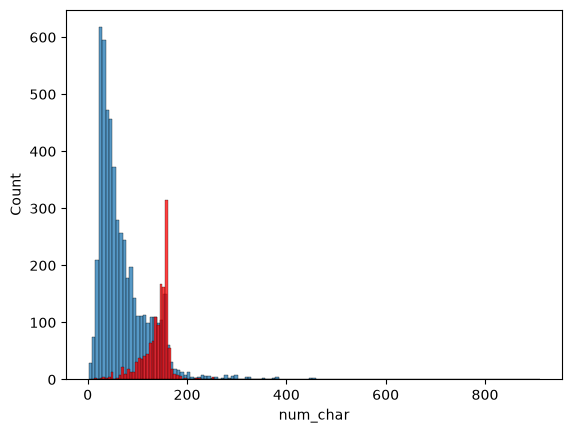

In [23]:
import seaborn as sns
sns.histplot(df[df["target"]==0]["num_char"])
sns.histplot(df[df["target"]==1]["num_char"],color="red")

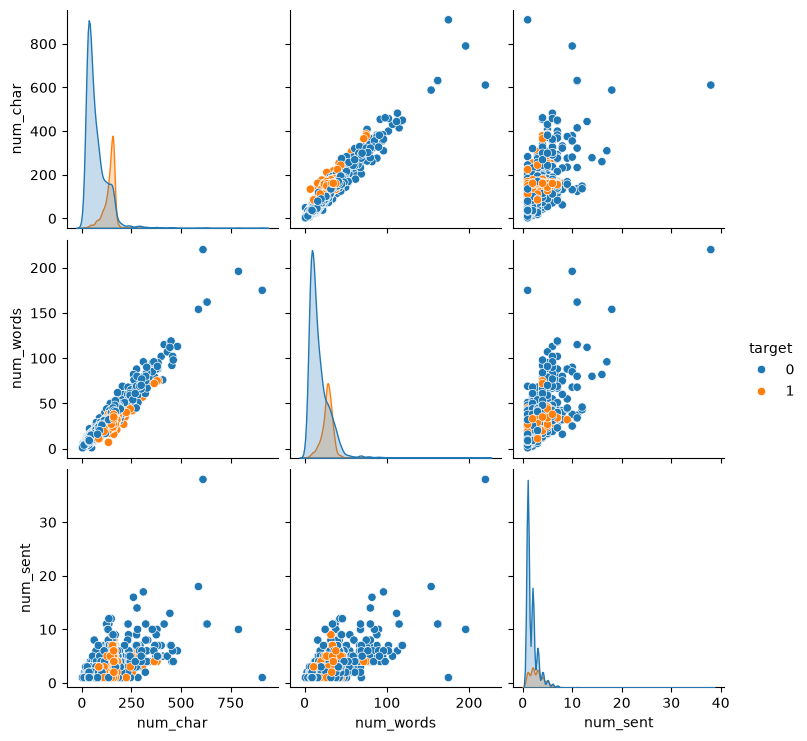

In [24]:
sns.pairplot(df,hue="target")

<Axes: >

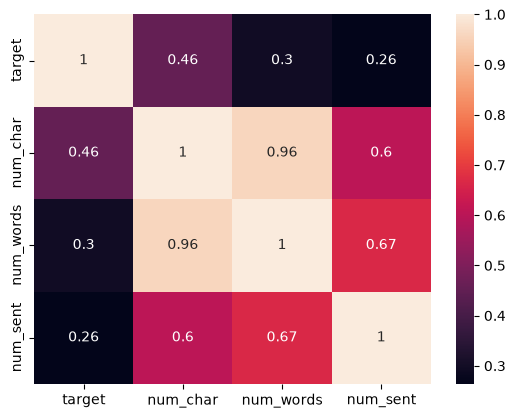

In [25]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [26]:
import nltk
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer

nltk.download("stopwords")

ps=PorterStemmer()

def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)

    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

[nltk_data] Downloading package stopwords to C:\Users\Yashvendra
[nltk_data]     Vyas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
df["transformed_text"]=df["text"].apply(transform_text)
df.head()

,target,text,num_char,num_words,num_sent,transformed_text
0,0,Your opinion about me? 1. Over 2. Jada 3. Kusr...,136,37,11,opinion jada kusruthi lovabl silent spl charac...
1,0,What's up? Do you want me to come online? If y...,81,20,3,want come onlin free talk
2,0,So u workin overtime nigpun?,28,6,1,u workin overtim nigpun
3,0,"Also sir, i sent you an email about how to log...",173,37,3,also sir sent email log usc payment portal sen...
4,1,Please Stay At Home. To encourage the notion o...,154,27,4,pleas stay home encourag notion stay home citi...


In [28]:
!pip install wordcloud


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color="white")


In [30]:
spam_wc=wc.generate(df[df["target"]==1]["transformed_text"].str.cat(sep=" "))

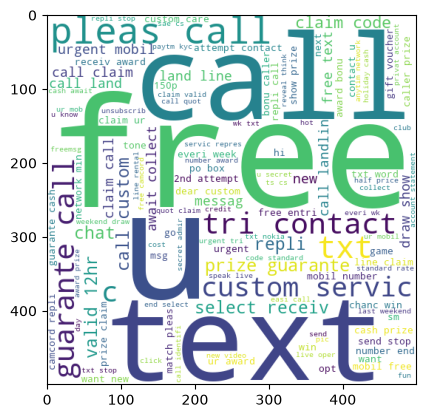

In [31]:
plt.Figure(figsize=(12,6))
plt.imshow(spam_wc)

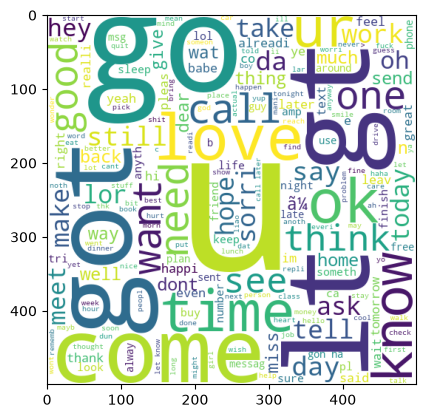

In [32]:
ham_wc=wc.generate(df[df["target"]==0]["transformed_text"].str.cat(sep=" "))
plt.Figure(figsize=(12,6))
plt.imshow(ham_wc)

In [33]:
spam_corpus=[ ]
for msg in df[df["target"]==1]["transformed_text"].tolist():
    for word in msg.split():
        spam_corpus.append(word)
len(spam_corpus)

20939

In [34]:
!pip install collection


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


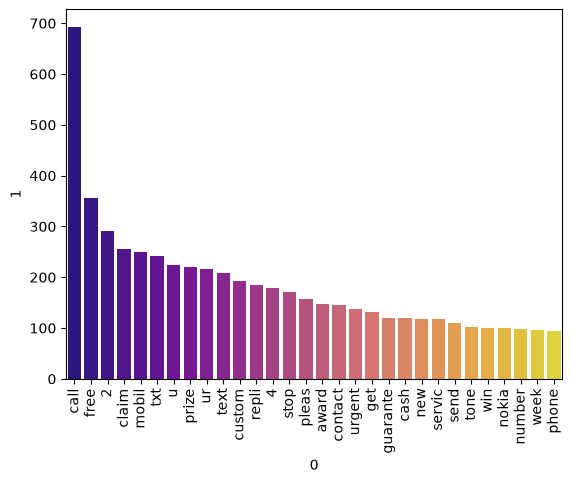

In [35]:
from collections import Counter
temp_df=pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x=temp_df[0],y=temp_df[1],hue=temp_df[0],palette="plasma")
plt.xticks(rotation="vertical")
plt.show()

In [36]:
ham_corpus=[ ]
for msg in df[df["target"]==0]["transformed_text"].tolist():
    for word in msg.split():
        ham_corpus.append(word)
len(ham_corpus)

43444

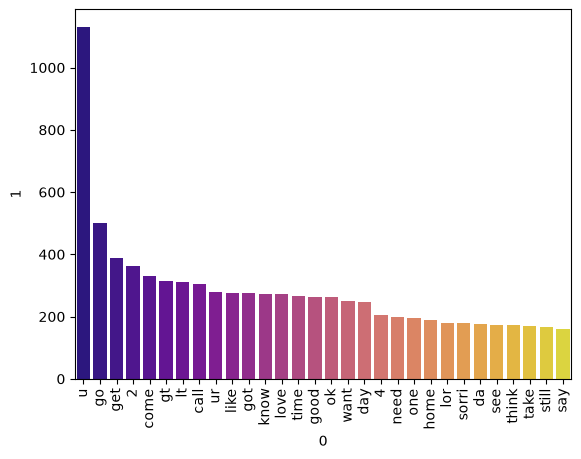

In [37]:
from collections import Counter
temp=pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(x=temp[0],y=temp[1],hue=temp[0],palette="plasma")
plt.xticks(rotation="vertical")
plt.show()

In [38]:
df.head()

,target,text,num_char,num_words,num_sent,transformed_text
0,0,Your opinion about me? 1. Over 2. Jada 3. Kusr...,136,37,11,opinion jada kusruthi lovabl silent spl charac...
1,0,What's up? Do you want me to come online? If y...,81,20,3,want come onlin free talk
2,0,So u workin overtime nigpun?,28,6,1,u workin overtim nigpun
3,0,"Also sir, i sent you an email about how to log...",173,37,3,also sir sent email log usc payment portal sen...
4,1,Please Stay At Home. To encourage the notion o...,154,27,4,pleas stay home encourag notion stay home citi...


In [39]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer()

In [40]:
x=tfidf.fit_transform(df["transformed_text"]).toarray() 

In [41]:
x.shape

(6808, 7358)

In [42]:
y=df["target"].values

In [43]:
y

array([0, 0, 0, ..., 1, 1, 0], shape=(6808,))

In [44]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [45]:
gnb.fit(x_train,y_train)
y_pred1=gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8604992657856094
[[897 173]
 [ 17 275]]
0.6138392857142857


In [46]:
mnb.fit(x_train,y_train)
y_pred2=mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9772393538913363
[[1067    3]
 [  28  264]]
0.9887640449438202


In [47]:
bnb.fit(x_train,y_train)
y_pred3=bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9809104258443465
[[1065    5]
 [  21  271]]
0.9818840579710145


In [48]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred2))  # for mnb

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1070
           1       0.99      0.90      0.94       292

    accuracy                           0.98      1362
   macro avg       0.98      0.95      0.97      1362
weighted avg       0.98      0.98      0.98      1362



In [49]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred3))   # y_pred3 = bnb's predictions

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1070
           1       0.98      0.93      0.95       292

    accuracy                           0.98      1362
   macro avg       0.98      0.96      0.97      1362
weighted avg       0.98      0.98      0.98      1362



In [50]:
import pickle
pickle.dump(tfidf,open("vectorizer.pkl","wb"))
pickle.dump(bnb,open("model.pkl","wb"))